# Circuit Motif Spectroscopy: Paper-Ready Visualization Pipeline

This notebook demonstrates the **motif analysis pipeline** for neural network attribution graphs from Neuronpedia. It processes attribution graphs through:

1. **Graph construction** - Build pruned igraph DAGs from raw attribution data
2. **3-node motif census** - Count directed triad patterns (021D, 021U, 021C, 030T/FFL)
3. **Null-model Z-scores** - Degree-preserving DAG edge swaps for significance testing
4. **Weighted FFL features** - Feed-forward loop intensity, coherence, path dominance
5. **Graph statistics** - 10D structural features (density, degree stats, diameter, etc.)
6. **t-SNE embeddings** - 2D visualization of graph feature spaces
7. **Domain heatmaps** - Cross-domain motif spectrum comparisons
8. **Ablation analysis** - Hub node impact vs matched controls with bootstrap CIs
9. **Clustering evaluation** - Spectral clustering with Hungarian-aligned confusion matrices

**Data**: 16 attribution graphs (2 per domain) from Gemma-2-2B across 8 task domains.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph, loguru — NOT on Colab, always install
_pip('python-igraph==0.11.8')
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11; use 1.15.3 on Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         _scipy, 'matplotlib==3.10.0', 'seaborn==0.13.2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import sys
import os
import gc
import math
import random
import time
import itertools
from collections import Counter
from typing import Any

import numpy as np
import igraph
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats as scipy_stats
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print("All imports successful")

All imports successful


## Data Loading

Load the mini demo dataset (16 attribution graphs, 2 per domain) from GitHub with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter5_paper_ready_vis/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} graph records")
domain_counts = Counter(r["domain"] for r in data)
for d, c in sorted(domain_counts.items()):
    print(f"  {d}: {c}")
print(f"Domains: {sorted(domain_counts.keys())}")

Loaded 16 graph records
  antonym: 2
  arithmetic: 2
  code_completion: 2
  country_capital: 2
  multi_hop_reasoning: 2
  rhyme: 2
  sentiment: 2
  translation: 2
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']


## Configuration

All tunable parameters. Start with minimum values for fast iteration; scale up later.

In [5]:
# --- Tunable parameters ---
N_NULL_MODELS = 14         # Original: 30 (null models per graph for Z-scores)
SWAP_MULTIPLIER = 50       # Original: 100 (edge swap attempts = multiplier * n_edges)
PRUNE_PERCENTILE = 75      # Percentile threshold for edge pruning (keep as-is)
MIN_NODES = 5              # Original: 30 (minimum nodes after pruning; low for demo subsampled graphs)
SEED = 42                  # Random seed
ABLATION_GRAPHS = 16       # Original: 50 (graphs for ablation analysis)
N_BOOTSTRAP = 500          # Original: 2000 (bootstrap resamples for CIs)
TSNE_PERPLEXITIES = [5, 10]  # Original: [15, 30, 50] (t-SNE perplexity values; low for 16 points)

DOMAINS = ["antonym", "arithmetic", "code_completion", "country_capital",
           "multi_hop_reasoning", "rhyme", "sentiment", "translation"]

random.seed(SEED)
np.random.seed(SEED)
print(f"Config: N_NULL={N_NULL_MODELS}, SWAP_MULT={SWAP_MULTIPLIER}, "
      f"PRUNE={PRUNE_PERCENTILE}%, MIN_NODES={MIN_NODES}, "
      f"ABLATION={ABLATION_GRAPHS}, BOOTSTRAP={N_BOOTSTRAP}")

Config: N_NULL=14, SWAP_MULT=50, PRUNE=75%, MIN_NODES=5, ABLATION=16, BOOTSTRAP=500


## Utility Functions

JSON sanitizer, graph construction, isoclass mapping, motif census, null model, and Z-score computation.

In [6]:
def sanitize_for_json(obj: Any) -> Any:
    """Recursively convert numpy types to Python natives for JSON."""
    if isinstance(obj, dict):
        return {sanitize_for_json(k): sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_for_json(x) for x in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        if math.isnan(v) or math.isinf(v):
            return 0.0
        return v
    if isinstance(obj, np.ndarray):
        return sanitize_for_json(obj.tolist())
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return 0.0
    return obj


def build_igraph(record: dict, prune_percentile: int) -> igraph.Graph:
    """Build a pruned igraph.Graph, preserving signed_weight attribute."""
    nodes = record["nodes"]
    links = record["links"]

    node_ids = [n["node_id"] for n in nodes]
    node_id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    layers, features, feature_types = [], [], []
    for n in nodes:
        try:
            layers.append(int(n.get("layer", 0)))
        except (ValueError, TypeError):
            layers.append(0)
        try:
            features.append(int(n.get("feature", 0)))
        except (ValueError, TypeError):
            features.append(0)
        feature_types.append(n.get("feature_type", ""))

    all_abs_weights = [abs(link.get("weight", 0.0)) for link in links]
    threshold = float(np.percentile(all_abs_weights, prune_percentile)) if all_abs_weights else 0.0

    edges, edge_weights, signed_weights = [], [], []
    for link in links:
        raw_w = link.get("weight", 0.0)
        w = abs(raw_w)
        if w >= threshold:
            src = node_id_to_idx.get(link.get("source"))
            tgt = node_id_to_idx.get(link.get("target"))
            if src is not None and tgt is not None and src != tgt:
                edges.append((src, tgt))
                edge_weights.append(w)
                signed_weights.append(raw_w)

    g = igraph.Graph(n=len(node_ids), edges=edges, directed=True)
    g.vs["node_id"] = node_ids
    g.vs["layer"] = layers
    g.vs["feature"] = features
    g.vs["feature_type"] = feature_types
    if edge_weights:
        g.es["weight"] = edge_weights
        g.es["signed_weight"] = signed_weights

    g = g.simplify(multiple=True, loops=True, combine_edges={"weight": "max", "signed_weight": "max"})

    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    if isolated:
        g.delete_vertices(isolated)

    if not g.is_dag():
        raise ValueError("Graph is not DAG after pruning")
    return g


def build_isoclass_mapping() -> tuple[dict, list[int], dict[int, str]]:
    """Build mapping from igraph isoclass IDs to MAN labels for 3-node triads."""
    mapping: dict[int, dict] = {}
    dag_valid: list[int] = []

    for cls_id in range(16):
        g = igraph.Graph.Isoclass(n=3, cls=cls_id, directed=True)
        edge_list = g.get_edgelist()
        mapping[cls_id] = {
            "edges": edge_list,
            "n_edges": len(edge_list),
            "is_connected": g.is_connected(mode="weak"),
            "is_dag": g.is_dag(),
        }
        if g.is_connected(mode="weak") and g.is_dag():
            dag_valid.append(cls_id)

    names: dict[int, str] = {}
    for cls_id in dag_valid:
        n_edges = mapping[cls_id]["n_edges"]
        edges = mapping[cls_id]["edges"]
        g = igraph.Graph(n=3, edges=edges, directed=True)
        in_degs = g.indegree()
        out_degs = g.outdegree()
        if n_edges == 3:
            names[cls_id] = "030T"
        elif n_edges == 2:
            if max(out_degs) == 2:
                names[cls_id] = "021D"
            elif max(in_degs) == 2:
                names[cls_id] = "021U"
            else:
                names[cls_id] = "021C"
        else:
            names[cls_id] = f"unknown_{n_edges}edges"

    return mapping, dag_valid, names


def compute_motif_census(g: igraph.Graph, dag_valid_ids: list[int]) -> dict[int, int]:
    raw = g.motifs_randesu(size=3)
    counts = [0 if (x != x) else int(x) for x in raw]
    return {idx: counts[idx] for idx in dag_valid_ids}


def _generate_null_edges(
    n_nodes: int, edges: list[tuple[int, int]], topo_rank: list[int],
    n_swap_attempts: int, seed: int,
) -> list[tuple[int, int]]:
    rng = random.Random(seed)
    edge_list = list(edges)
    n_edges = len(edge_list)
    if n_edges < 2:
        return edge_list
    adj_set = set(edge_list)
    for _ in range(n_swap_attempts):
        i1 = rng.randint(0, n_edges - 1)
        i2 = rng.randint(0, n_edges - 1)
        if i1 == i2:
            continue
        u1, v1 = edge_list[i1]
        u2, v2 = edge_list[i2]
        if u1 == u2 or v1 == v2:
            continue
        new_e1, new_e2 = (u1, v2), (u2, v1)
        if new_e1 in adj_set or new_e2 in adj_set:
            continue
        if topo_rank[u1] >= topo_rank[v2] or topo_rank[u2] >= topo_rank[v1]:
            continue
        adj_set.discard((u1, v1))
        adj_set.discard((u2, v2))
        adj_set.add(new_e1)
        adj_set.add(new_e2)
        edge_list[i1] = new_e1
        edge_list[i2] = new_e2
    return edge_list


def generate_null_census(
    g: igraph.Graph, dag_valid_ids: list[int], n_null: int,
) -> list[dict[int, int]]:
    """Generate null model motif counts (sequential, no multiprocessing for notebook)."""
    n_nodes = g.vcount()
    edges = [tuple(e.tuple) for e in g.es]
    topo_order = g.topological_sorting()
    topo_rank = [0] * n_nodes
    for rank, node in enumerate(topo_order):
        topo_rank[node] = rank
    n_swap = SWAP_MULTIPLIER * len(edges)

    results = []
    for seed in range(n_null):
        new_edges = _generate_null_edges(n_nodes, edges, topo_rank, n_swap, seed)
        g_null = igraph.Graph(n=n_nodes, edges=new_edges, directed=True)
        raw = g_null.motifs_randesu(size=3)
        counts = [0 if (x != x) else int(x) for x in raw]
        results.append({idx: counts[idx] for idx in dag_valid_ids})
        del g_null
    return results


def compute_zscores(
    real_counts: dict[int, int], null_list: list[dict[int, int]],
    dag_valid_ids: list[int],
) -> dict[str, Any]:
    z_scores, null_means, null_stds = {}, {}, {}
    for mid in dag_valid_ids:
        real_val = real_counts[mid]
        nulls = np.array([nc[mid] for nc in null_list], dtype=float)
        mu, sigma = float(np.mean(nulls)), float(np.std(nulls))
        null_means[mid] = mu
        null_stds[mid] = sigma
        if sigma == 0:
            z_scores[mid] = 0.0 if real_val == mu else (10.0 if real_val > mu else -10.0)
        else:
            z_scores[mid] = float((real_val - mu) / sigma)
    return {"z_scores": z_scores, "null_means": null_means, "null_stds": null_stds}

print("Utility functions defined")

Utility functions defined


## Feature Extraction Functions

FFL enumeration, weighted motif features, graph statistics, spectral clustering, confusion matrices, and ablation analysis.

In [7]:
def enumerate_ffls(g: igraph.Graph) -> list[dict]:
    """Enumerate all feed-forward loop (030T) instances: A->B, A->C, B->C."""
    adj_set: set[tuple[int, int]] = set()
    weight_map: dict[tuple[int, int], float] = {}
    signed_map: dict[tuple[int, int], float] = {}

    has_weight = "weight" in g.es.attributes() if g.ecount() > 0 else False
    has_signed = "signed_weight" in g.es.attributes() if g.ecount() > 0 else False

    for e in g.es:
        edge = (e.source, e.target)
        adj_set.add(edge)
        weight_map[edge] = e["weight"] if has_weight else 1.0
        signed_map[edge] = e["signed_weight"] if has_signed else weight_map[edge]

    successors: dict[int, list[int]] = {}
    for s, t in adj_set:
        successors.setdefault(s, []).append(t)

    ffls = []
    for a, succs in successors.items():
        if len(succs) < 2:
            continue
        for i in range(len(succs)):
            for j in range(len(succs)):
                if i == j:
                    continue
                b, c = succs[i], succs[j]
                if (b, c) in adj_set:
                    w_ab = weight_map[(a, b)]
                    w_ac = weight_map[(a, c)]
                    w_bc = weight_map[(b, c)]
                    sw_ab = signed_map[(a, b)]
                    sw_ac = signed_map[(a, c)]
                    sw_bc = signed_map[(b, c)]
                    intensity = (w_ab * w_ac * w_bc) ** (1.0 / 3.0)
                    denom_pd = w_ab * w_bc
                    path_dom = w_ac / denom_pd if denom_pd > 1e-12 else 0.0
                    is_coherent = (1 if sw_ab > 0 else -1) * (1 if sw_ac > 0 else -1) * (1 if sw_bc > 0 else -1) > 0
                    denom_wa = w_ab + w_bc
                    w_asym = abs(w_ab - w_bc) / denom_wa if denom_wa > 1e-12 else 0.0
                    ffls.append({
                        "a": a, "b": b, "c": c,
                        "w_ab": w_ab, "w_ac": w_ac, "w_bc": w_bc,
                        "intensity": intensity,
                        "path_dominance": path_dom,
                        "is_coherent": is_coherent,
                        "weight_asymmetry": w_asym,
                    })
    return ffls


def compute_weighted_features(ffls: list[dict], motif_ratios: np.ndarray) -> np.ndarray:
    """Compute ~12D weighted feature vector from FFL instances + motif ratios."""
    if not ffls:
        return np.concatenate([np.zeros(8), motif_ratios])
    intensities = np.array([f["intensity"] for f in ffls])
    path_doms = np.array([f["path_dominance"] for f in ffls])
    coherences = np.array([f["is_coherent"] for f in ffls], dtype=float)
    asymmetries = np.array([f["weight_asymmetry"] for f in ffls])
    weighted_feats = np.array([
        float(np.mean(intensities)), float(np.median(intensities)),
        float(np.std(intensities)), float(np.mean(coherences)),
        float(np.mean(path_doms)), float(np.mean(asymmetries)),
        float(len(ffls)),
        float(len(ffls)) / max(1.0, float(sum(motif_ratios > 0))),
    ])
    return np.concatenate([weighted_feats, motif_ratios])


def compute_graph_stats(g: igraph.Graph) -> np.ndarray:
    n = g.vcount()
    m = g.ecount()
    in_degs = np.array(g.indegree(), dtype=float) if n > 0 else np.array([0.0])
    out_degs = np.array(g.outdegree(), dtype=float) if n > 0 else np.array([0.0])
    layers = set(g.vs["layer"]) if "layer" in g.vs.attributes() else {0}
    has_w = "weight" in g.es.attributes() if m > 0 else False
    weights = np.array(g.es["weight"], dtype=float) if has_w else np.array([0.0])
    try:
        comps = g.connected_components(mode="weak")
        largest = comps.giant()
        diam = largest.diameter(directed=True) if largest.vcount() > 1 else 0
    except Exception:
        diam = 0
    return np.array([
        n, m, g.density() if n > 1 else 0.0,
        float(np.mean(in_degs)), float(np.mean(out_degs)),
        float(np.max(out_degs)) if n > 0 else 0.0,
        len(layers), diam,
        float(np.mean(weights)), float(np.std(weights)),
    ])


def _safe_spectral_cluster(affinity: np.ndarray, n_clusters: int, seed: int = 42) -> np.ndarray:
    n = affinity.shape[0]
    degrees = affinity.sum(axis=1)
    degrees = np.maximum(degrees, 1e-10)
    d_inv_sqrt = 1.0 / np.sqrt(degrees)
    L_norm = np.eye(n) - (d_inv_sqrt[:, None] * affinity * d_inv_sqrt[None, :])
    eigenvalues, eigenvectors = np.linalg.eigh(L_norm)
    embedding = eigenvectors[:, :n_clusters].copy()
    norms = np.linalg.norm(embedding, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    embedding = embedding / norms
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10, max_iter=300)
    return km.fit_predict(embedding)


def build_confusion_with_hungarian(
    true_labels: np.ndarray, pred_labels: np.ndarray,
    n_true_classes: int, n_pred_clusters: int,
) -> tuple[np.ndarray, list[int]]:
    cm = np.zeros((n_true_classes, n_pred_clusters), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        cm[t, p] += 1
    row_ind, col_ind = linear_sum_assignment(-cm)
    aligned_order = list(col_ind)
    cm_aligned = cm[:, aligned_order]
    return cm_aligned, aligned_order


def compute_ablation_data(
    graphs: list, graph_indices: list[int],
    all_ffls: list[list[dict]], domains: list[str],
) -> dict:
    """Compute ablation impact for hub vs control nodes."""
    hub_impacts, control_degree, control_random, control_layer = [], [], [], []
    mpi_impact_pairs = []

    for idx, gi in enumerate(graph_indices):
        g = graphs[gi]
        if g is None:
            continue
        ffls = all_ffls[gi]
        if not ffls or g.vcount() < MIN_NODES:
            continue
        total_weight = sum(g.es["weight"]) if g.ecount() > 0 else 1.0
        if total_weight < 1e-12:
            continue
        mpi: dict[int, int] = {}
        for ffl in ffls:
            for node_key in ["a", "b", "c"]:
                nid = ffl[node_key]
                mpi[nid] = mpi.get(nid, 0) + 1
        if not mpi:
            continue
        sorted_nodes = sorted(mpi.keys(), key=lambda x: mpi[x], reverse=True)
        n_hub = max(1, len(sorted_nodes) // 10)
        hub_nodes = sorted_nodes[:n_hub]

        for nid in mpi:
            if nid >= g.vcount():
                continue
            incident = g.incident(nid, mode="all")
            node_impact = sum(g.es[e]["weight"] for e in incident) / total_weight
            mpi_impact_pairs.append((float(mpi[nid]), float(node_impact)))

        for hub in hub_nodes:
            if hub >= g.vcount():
                continue
            incident = g.incident(hub, mode="all")
            hub_impact = sum(g.es[e]["weight"] for e in incident) / total_weight
            hub_impacts.append(hub_impact)
            hub_deg = g.degree(hub)
            hub_layer = g.vs[hub]["layer"]
            candidates = [v for v in range(g.vcount())
                          if v != hub and v not in hub_nodes
                          and abs(g.degree(v) - hub_deg) <= 2]
            if candidates:
                cv = random.choice(candidates)
                inc = g.incident(cv, mode="all")
                control_degree.append(sum(g.es[e]["weight"] for e in inc) / total_weight)
            layer_cands = [v for v in range(g.vcount())
                           if v != hub and v not in hub_nodes
                           and g.vs[v]["layer"] == hub_layer]
            if layer_cands:
                cv = random.choice(layer_cands)
                inc = g.incident(cv, mode="all")
                control_layer.append(sum(g.es[e]["weight"] for e in inc) / total_weight)
            rand_cands = [v for v in range(g.vcount()) if v != hub and v not in hub_nodes]
            if rand_cands:
                cv = random.choice(rand_cands)
                inc = g.incident(cv, mode="all")
                control_random.append(sum(g.es[e]["weight"] for e in inc) / total_weight)

    def bootstrap_ci(vals, n_boot=N_BOOTSTRAP):
        if not vals:
            return (0.0, 0.0)
        arr = np.array(vals)
        rng = np.random.RandomState(SEED)
        medians = [float(np.median(rng.choice(arr, size=len(arr), replace=True))) for _ in range(n_boot)]
        return (float(np.percentile(medians, 2.5)), float(np.percentile(medians, 97.5)))

    hub_med = float(np.median(hub_impacts)) if hub_impacts else 0.0
    hub_ci = bootstrap_ci(hub_impacts)
    bar_chart = {"control_types": []}
    for name, vals in [("degree_matched", control_degree),
                       ("layer_matched", control_layer),
                       ("random", control_random)]:
        c_med = float(np.median(vals)) if vals else 0.0
        c_ci = bootstrap_ci(vals)
        ratio = hub_med / c_med if c_med > 1e-12 else 0.0
        bar_chart["control_types"].append({
            "name": name, "hub_median": hub_med, "control_median": c_med,
            "ratio": ratio, "ci_95_lo": c_ci[0], "ci_95_hi": c_ci[1],
            "hub_ci_95_lo": hub_ci[0], "hub_ci_95_hi": hub_ci[1],
            "n_comparisons": len(vals),
        })
    return {"bar_chart": bar_chart, "n_graphs_used": len(graph_indices), "n_hub_total": len(hub_impacts)}


def compute_confusion_matrices(
    feature_matrices: dict[str, np.ndarray],
    true_labels: np.ndarray, domain_names: list[str],
) -> dict:
    domains_sorted = sorted(set(domain_names))
    n_classes = len(domains_sorted)
    results = {}
    for feat_name, X in feature_matrices.items():
        try:
            sim = cosine_similarity(X)
            affinity = (sim + 1.0) / 2.0
            np.fill_diagonal(affinity, 1.0)
            affinity = np.clip(affinity, 0, None)
            pred = _safe_spectral_cluster(affinity, n_classes, SEED)
            nmi = float(normalized_mutual_info_score(true_labels, pred))
            ari = float(adjusted_rand_score(true_labels, pred))
            cm_aligned, aligned_order = build_confusion_with_hungarian(
                true_labels, pred, n_classes, n_classes)
            results[feat_name] = {
                "matrix": cm_aligned.tolist(), "domain_order": domains_sorted,
                "cluster_order": aligned_order, "nmi": nmi, "ari": ari,
            }
        except Exception as exc:
            print(f"  Confusion matrix failed for {feat_name}: {exc}")
            results[feat_name] = {"matrix": [], "domain_order": domains_sorted,
                                  "cluster_order": [], "nmi": 0.0, "ari": 0.0}
    return results

print("Feature extraction functions defined")

Feature extraction functions defined


## Step 1-2: Build Isoclass Mapping and Pruned Graphs

Identify valid 3-node DAG motif types and construct pruned igraph DAGs from the raw attribution data.

In [8]:
t_start = time.time()
all_records = data  # Already loaded from mini_demo_data.json
n_total = len(all_records)
domain_labels = [r["domain"] for r in all_records]
slugs = [r["slug"] for r in all_records]
correctness_list = [r["model_correct"] for r in all_records]
domains_sorted = sorted(set(domain_labels))
le = LabelEncoder()
le.fit(domains_sorted)
true_labels = le.transform(domain_labels)
n_classes = len(domains_sorted)

# Build isoclass mapping
mapping, dag_valid_ids, names = build_isoclass_mapping()
motif_names = [names[cid] for cid in dag_valid_ids]
print(f"DAG-valid 3-node types: {dag_valid_ids} -> {motif_names}")

# Build pruned graphs
pruned_graphs: list = [None] * n_total
valid_indices: list[int] = []

for i, rec in enumerate(all_records):
    try:
        g = build_igraph(rec, PRUNE_PERCENTILE)
        if g.vcount() >= MIN_NODES:
            pruned_graphs[i] = g
            valid_indices.append(i)
        else:
            print(f"  Graph {i} too small: {g.vcount()} nodes")
    except Exception as exc:
        print(f"  Failed graph {i} ({rec['domain']}): {exc}")

gc.collect()
print(f"\nValid graphs: {len(valid_indices)}/{n_total}")
if valid_indices:
    nc = [pruned_graphs[i].vcount() for i in valid_indices]
    ec = [pruned_graphs[i].ecount() for i in valid_indices]
    print(f"  Nodes: min={min(nc)}, med={np.median(nc):.0f}, max={max(nc)}")
    print(f"  Edges: min={min(ec)}, med={np.median(ec):.0f}, max={max(ec)}")

DAG-valid 3-node types: [2, 4, 6, 7] -> ['021U', '021C', '021D', '030T']

Valid graphs: 16/16
  Nodes: min=77, med=84, max=93
  Edges: min=75, med=75, max=75


## Step 3-4: Motif Census + Null-Model Z-Scores

Count 3-node motif occurrences in each graph, then generate degree-preserving DAG null models to compute significance Z-scores.

In [9]:
motif_count_ratios = np.zeros((n_total, len(dag_valid_ids)))
real_census: dict[int, dict[int, int]] = {}
z_data: list[dict] = [{}] * n_total
all_ffls: list[list[dict]] = [[] for _ in range(n_total)]

# Real census
t_census = time.time()
for gi in valid_indices:
    g = pruned_graphs[gi]
    try:
        census = compute_motif_census(g, dag_valid_ids)
        real_census[gi] = census
        total = sum(census[mid] for mid in dag_valid_ids)
        if total > 0:
            motif_count_ratios[gi] = [census[mid] / total for mid in dag_valid_ids]
    except Exception as exc:
        print(f"  Census failed graph {gi}: {exc}")
print(f"Real census done in {time.time() - t_census:.1f}s")

# Null models + Z-scores
t_null = time.time()
for gi in valid_indices:
    g = pruned_graphs[gi]
    try:
        null_list = generate_null_census(g, dag_valid_ids, N_NULL_MODELS)
        z_result = compute_zscores(real_census[gi], null_list, dag_valid_ids)
        z_data[gi] = z_result
        del null_list
    except Exception as exc:
        print(f"  Null model failed graph {gi}: {exc}")
gc.collect()
print(f"Z-scores completed in {time.time() - t_null:.1f}s for {len(valid_indices)} graphs x {N_NULL_MODELS} null models")

Real census done in 0.0s


Z-scores completed in 0.7s for 16 graphs x 14 null models


## Step 5-7: Weighted Features, Graph Stats, and Feature Matrices

Enumerate feed-forward loops (FFLs), compute weighted motif features, graph-level statistics, and assemble standardized feature matrices for downstream analysis.

In [10]:
# Step 5: Weighted motif features (FFL enumeration)
t_ffl = time.time()
weighted_features = np.zeros((n_total, 8 + len(dag_valid_ids)))
for gi in valid_indices:
    g = pruned_graphs[gi]
    try:
        ffls = enumerate_ffls(g)
        all_ffls[gi] = ffls
        weighted_features[gi] = compute_weighted_features(ffls, motif_count_ratios[gi])
    except Exception as exc:
        print(f"  FFL failed graph {gi}: {exc}")
        weighted_features[gi] = compute_weighted_features([], motif_count_ratios[gi])
ffl_counts = [len(all_ffls[gi]) for gi in valid_indices]
print(f"FFL enumeration done in {time.time() - t_ffl:.1f}s")
print(f"  FFLs per graph: min={min(ffl_counts)}, med={np.median(ffl_counts):.0f}, max={max(ffl_counts)}")

# Step 6: Graph statistics (10D)
graph_stats = np.zeros((n_total, 10))
for gi in valid_indices:
    try:
        graph_stats[gi] = compute_graph_stats(pruned_graphs[gi])
    except Exception as exc:
        print(f"  Stats failed graph {gi}: {exc}")
print("Graph statistics computed")

# Step 7: Feature matrix construction
vi = np.array(valid_indices)
motif_only = motif_count_ratios[vi]
graph_only = graph_stats[vi]
weighted_only = weighted_features[vi]
all_combined = np.hstack([motif_only, graph_only, weighted_only])

scaler_m = StandardScaler().fit(motif_only)
scaler_g = StandardScaler().fit(graph_only)
scaler_w = StandardScaler().fit(weighted_only)
scaler_a = StandardScaler().fit(all_combined)

motif_scaled = scaler_m.transform(motif_only)
graph_scaled = scaler_g.transform(graph_only)
weighted_scaled = scaler_w.transform(weighted_only)
all_scaled = scaler_a.transform(all_combined)

for arr in [motif_scaled, graph_scaled, weighted_scaled, all_scaled]:
    arr[np.isnan(arr)] = 0.0

feature_matrices = {
    "motif_only": motif_scaled,
    "graph_stats_only": graph_scaled,
    "weighted_motif_only": weighted_scaled,
    "all_combined": all_scaled,
}

feat_name_map = {
    "motif_only": motif_names,
    "graph_stats_only": ["n_nodes", "n_edges", "density", "mean_in_deg",
                         "mean_out_deg", "max_out_deg", "n_layers", "diameter",
                         "mean_weight", "std_weight"],
    "weighted_motif_only": ["ffl_intensity_mean", "ffl_intensity_median",
                            "ffl_intensity_std", "ffl_coherence_frac",
                            "ffl_path_dominance_mean", "ffl_weight_asymmetry_mean",
                            "ffl_count", "ffl_density"] + motif_names,
    "all_combined": [],
}
feat_name_map["all_combined"] = (feat_name_map["motif_only"]
                                 + feat_name_map["graph_stats_only"]
                                 + feat_name_map["weighted_motif_only"])

valid_domains = [domain_labels[i] for i in valid_indices]
valid_slugs = [slugs[i] for i in valid_indices]
valid_correct = [correctness_list[i] for i in valid_indices]
valid_true_labels = le.transform(valid_domains)

print(f"Feature shapes: motif={motif_scaled.shape}, graph={graph_scaled.shape}, "
      f"weighted={weighted_scaled.shape}, combined={all_scaled.shape}")

FFL enumeration done in 0.0s
  FFLs per graph: min=0, med=2, max=7
Graph statistics computed
Feature shapes: motif=(16, 4), graph=(16, 10), weighted=(16, 12), combined=(16, 26)


## Step 8-12: Embeddings, Ablation, and Clustering Evaluation

Compute t-SNE embeddings, ablation impact analysis (hub vs control nodes), and spectral clustering confusion matrices with Hungarian alignment.

In [11]:
# Step 8: t-SNE Embeddings
t_emb = time.time()
embeddings_list = []
best_overall = {"method": "", "feature_set": "", "hyperparams": {}, "silhouette": -1.0}
domain_encoded = le.transform(valid_domains)

for feat_name, X in feature_matrices.items():
    n = X.shape[0]
    for perp in TSNE_PERPLEXITIES:
        effective_perp = min(perp, n - 1)
        if effective_perp < 2:
            continue
        try:
            emb = TSNE(n_components=2, perplexity=effective_perp,
                       random_state=SEED, max_iter=1000, init="pca",
                       learning_rate="auto").fit_transform(X)
            points = [{"x": float(emb[i, 0]), "y": float(emb[i, 1]),
                       "domain": valid_domains[i], "slug": valid_slugs[i],
                       "correctness": valid_correct[i]} for i in range(n)]
            sil = -1.0
            if len(set(valid_domains)) > 1:
                try:
                    sil = float(silhouette_score(emb, domain_encoded))
                except Exception:
                    pass
            rec = {"method": "tsne", "feature_set": feat_name,
                   "hyperparams": {"perplexity": effective_perp},
                   "points": points, "silhouette_score": sil, "is_recommended": False}
            embeddings_list.append(rec)
            if sil > best_overall["silhouette"]:
                best_overall = {"method": "tsne", "feature_set": feat_name,
                                "hyperparams": {"perplexity": effective_perp}, "silhouette": sil}
        except Exception as exc:
            print(f"  t-SNE failed: {feat_name} perp={effective_perp}: {exc}")

for rec in embeddings_list:
    if (rec["method"] == best_overall["method"]
            and rec["feature_set"] == best_overall["feature_set"]
            and rec["hyperparams"] == best_overall.get("hyperparams", {})):
        rec["is_recommended"] = True

print(f"Embeddings: {len(embeddings_list)} computed in {time.time() - t_emb:.1f}s")
print(f"  Best: {best_overall['method']} / {best_overall['feature_set']} / sil={best_overall['silhouette']:.3f}")

# Step 9: Ablation analysis
t_abl = time.time()
n_per_domain = max(1, ABLATION_GRAPHS // n_classes)
ablation_indices = []
for d in domains_sorted:
    d_indices = [gi for gi in valid_indices if domain_labels[gi] == d]
    ablation_indices.extend(d_indices[:n_per_domain])
ablation_result = compute_ablation_data(pruned_graphs, ablation_indices, all_ffls, domain_labels)
print(f"Ablation done in {time.time() - t_abl:.1f}s, {ablation_result['n_hub_total']} hub nodes")

# Step 10: Confusion matrices (spectral clustering)
confusion_results = compute_confusion_matrices(feature_matrices, valid_true_labels, valid_domains)
best_nmi_feat, best_nmi_val = "", -1.0
for fn, cr in confusion_results.items():
    print(f"  {fn}: NMI={cr['nmi']:.3f}, ARI={cr['ari']:.3f}")
    if cr["nmi"] > best_nmi_val:
        best_nmi_val = cr["nmi"]
        best_nmi_feat = fn

# Baseline: random clustering
rng_bl = np.random.RandomState(SEED)
baseline_pred = rng_bl.randint(0, n_classes, size=len(valid_indices))
baseline_nmi = float(normalized_mutual_info_score(valid_true_labels, baseline_pred))
baseline_ari = float(adjusted_rand_score(valid_true_labels, baseline_pred))
print(f"  Baseline random: NMI={baseline_nmi:.3f}, ARI={baseline_ari:.3f}")

total_time = time.time() - t_start
print(f"\nTotal pipeline time: {total_time:.1f}s")

Embeddings: 8 computed in 0.8s
  Best: tsne / all_combined / sil=0.377
Ablation done in 0.0s, 11 hub nodes
  motif_only: NMI=0.756, ARI=0.239
  graph_stats_only: NMI=0.824, ARI=0.430
  weighted_motif_only: NMI=0.778, ARI=0.286
  all_combined: NMI=0.899, ARI=0.640
  Baseline random: NMI=0.605, ARI=0.060

Total pipeline time: 1.7s


## Results Visualization

Display key results: t-SNE embeddings colored by domain, motif Z-score distributions, ablation impact comparison, and clustering confusion matrix.

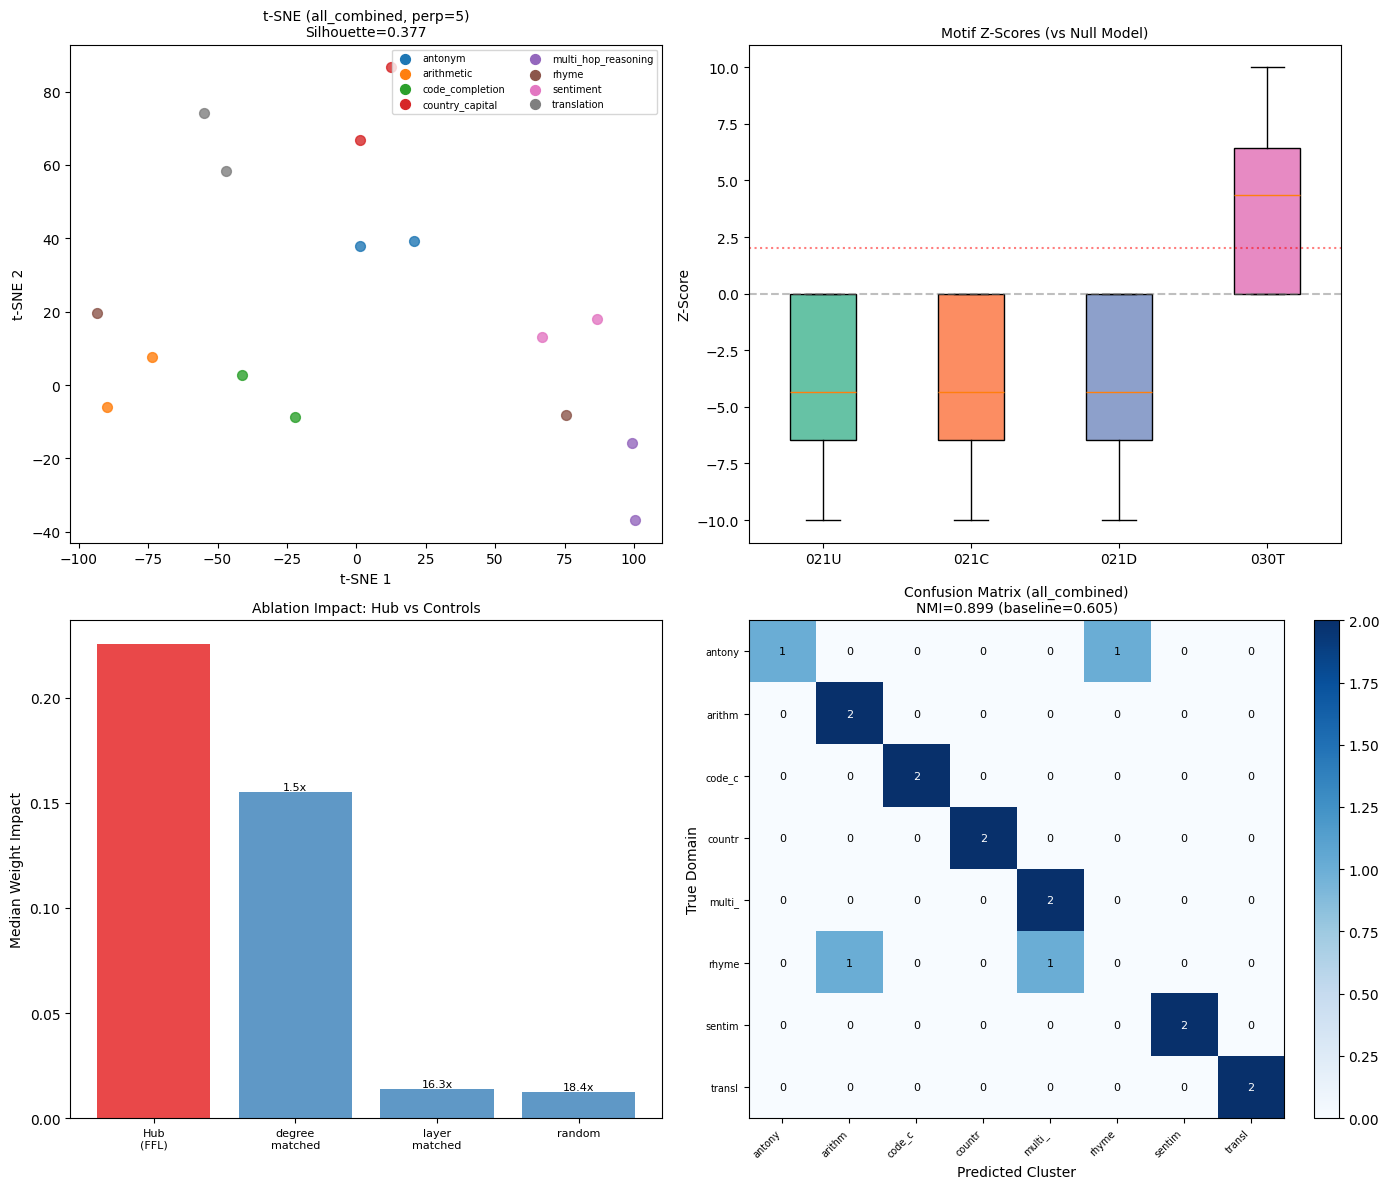


PIPELINE SUMMARY
Graphs processed:       16
Valid after pruning:     16
Domains:                 8
Motif types (3-node):    ['021U', '021C', '021D', '030T']
Null models per graph:   14
Best clustering NMI:     0.899 (all_combined)
Baseline NMI:            0.605
Best embedding sil:      0.377
Hub ablation nodes:      11
Total time:              1.7s


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1: Best t-SNE embedding ---
ax = axes[0, 0]
best_emb_rec = next((e for e in embeddings_list if e["is_recommended"]), embeddings_list[0] if embeddings_list else None)
if best_emb_rec:
    pts = best_emb_rec["points"]
    unique_domains = sorted(set(p["domain"] for p in pts))
    cmap = matplotlib.colormaps.get_cmap("tab10")
    domain_to_color = {d: cmap(i) for i, d in enumerate(unique_domains)}
    for p in pts:
        ax.scatter(p["x"], p["y"], c=[domain_to_color[p["domain"]]], s=50, alpha=0.8)
    # Legend
    for d in unique_domains:
        ax.scatter([], [], c=[domain_to_color[d]], label=d, s=50)
    ax.legend(fontsize=7, loc="best", ncol=2)
    ax.set_title(f"t-SNE ({best_emb_rec['feature_set']}, perp={best_emb_rec['hyperparams'].get('perplexity','')})\n"
                 f"Silhouette={best_emb_rec['silhouette_score']:.3f}", fontsize=10)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

# --- Plot 2: Motif Z-scores per type ---
ax = axes[0, 1]
zscore_by_motif = {mn: [] for mn in motif_names}
for gi in valid_indices:
    zd = z_data[gi]
    if zd and "z_scores" in zd:
        for j, cid in enumerate(dag_valid_ids):
            zscore_by_motif[motif_names[j]].append(zd["z_scores"].get(cid, 0.0))
box_data = [zscore_by_motif[mn] for mn in motif_names]
if any(len(b) > 0 for b in box_data):
    bp = ax.boxplot(box_data, tick_labels=motif_names, patch_artist=True)
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=2, color='red', linestyle=':', alpha=0.5, label='Z=2 (significant)')
ax.set_title("Motif Z-Scores (vs Null Model)", fontsize=10)
ax.set_ylabel("Z-Score")

# --- Plot 3: Ablation impact ---
ax = axes[1, 0]
bar_data = ablation_result["bar_chart"]["control_types"]
if bar_data:
    labels_abl = ["Hub\n(FFL)"] + [ct["name"].replace("_", "\n") for ct in bar_data]
    medians = [bar_data[0]["hub_median"]] + [ct["control_median"] for ct in bar_data]
    colors_abl = ['#e41a1c'] + ['#377eb8'] * len(bar_data)
    bars = ax.bar(range(len(labels_abl)), medians, color=colors_abl, alpha=0.8)
    ax.set_xticks(range(len(labels_abl)))
    ax.set_xticklabels(labels_abl, fontsize=8)
    ax.set_title("Ablation Impact: Hub vs Controls", fontsize=10)
    ax.set_ylabel("Median Weight Impact")
    # Add ratio annotations
    for i, ct in enumerate(bar_data):
        if ct["ratio"] > 0:
            ax.annotate(f'{ct["ratio"]:.1f}x', xy=(i+1, ct["control_median"]),
                       fontsize=8, ha='center', va='bottom')

# --- Plot 4: Confusion matrix (best feature set) ---
ax = axes[1, 1]
best_cm = confusion_results.get(best_nmi_feat, {})
if best_cm and best_cm.get("matrix"):
    cm = np.array(best_cm["matrix"])
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(best_cm["domain_order"])))
    ax.set_yticks(range(len(best_cm["domain_order"])))
    ax.set_xticklabels([d[:6] for d in best_cm["domain_order"]], rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels([d[:6] for d in best_cm["domain_order"]], fontsize=7)
    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                   color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_title(f"Confusion Matrix ({best_nmi_feat})\nNMI={best_cm['nmi']:.3f} (baseline={baseline_nmi:.3f})", fontsize=10)
    ax.set_xlabel("Predicted Cluster"); ax.set_ylabel("True Domain")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()

# Print summary table
print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"Graphs processed:       {n_total}")
print(f"Valid after pruning:     {len(valid_indices)}")
print(f"Domains:                 {n_classes}")
print(f"Motif types (3-node):    {motif_names}")
print(f"Null models per graph:   {N_NULL_MODELS}")
print(f"Best clustering NMI:     {best_nmi_val:.3f} ({best_nmi_feat})")
print(f"Baseline NMI:            {baseline_nmi:.3f}")
print(f"Best embedding sil:      {best_overall['silhouette']:.3f}")
print(f"Hub ablation nodes:      {ablation_result['n_hub_total']}")
print(f"Total time:              {total_time:.1f}s")
print("="*60)